# Drinking age with a scikit-learn model

This example uses the sharp regression discontinuity design to make claims about the causal effects of the minimum legal drinking age (21 in the USA) upon all cause mortality rates. The dataset is from a study by {cite:t}`carpenter2009effect`.

In [1]:
from sklearn.linear_model import LinearRegression

import causalpy as cp

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
df = (
    cp.load_data("drinking")
    .rename(columns={"agecell": "age"})
    .assign(treated=lambda df_: df_.age > 21)
    .dropna(axis=0)
)

In [4]:
result = cp.RegressionDiscontinuity(
    df,
    formula="all ~ 1 + age + treated",
    running_variable_name="age",
    model=LinearRegression(),
    treatment_threshold=21,
)

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


## Examine results

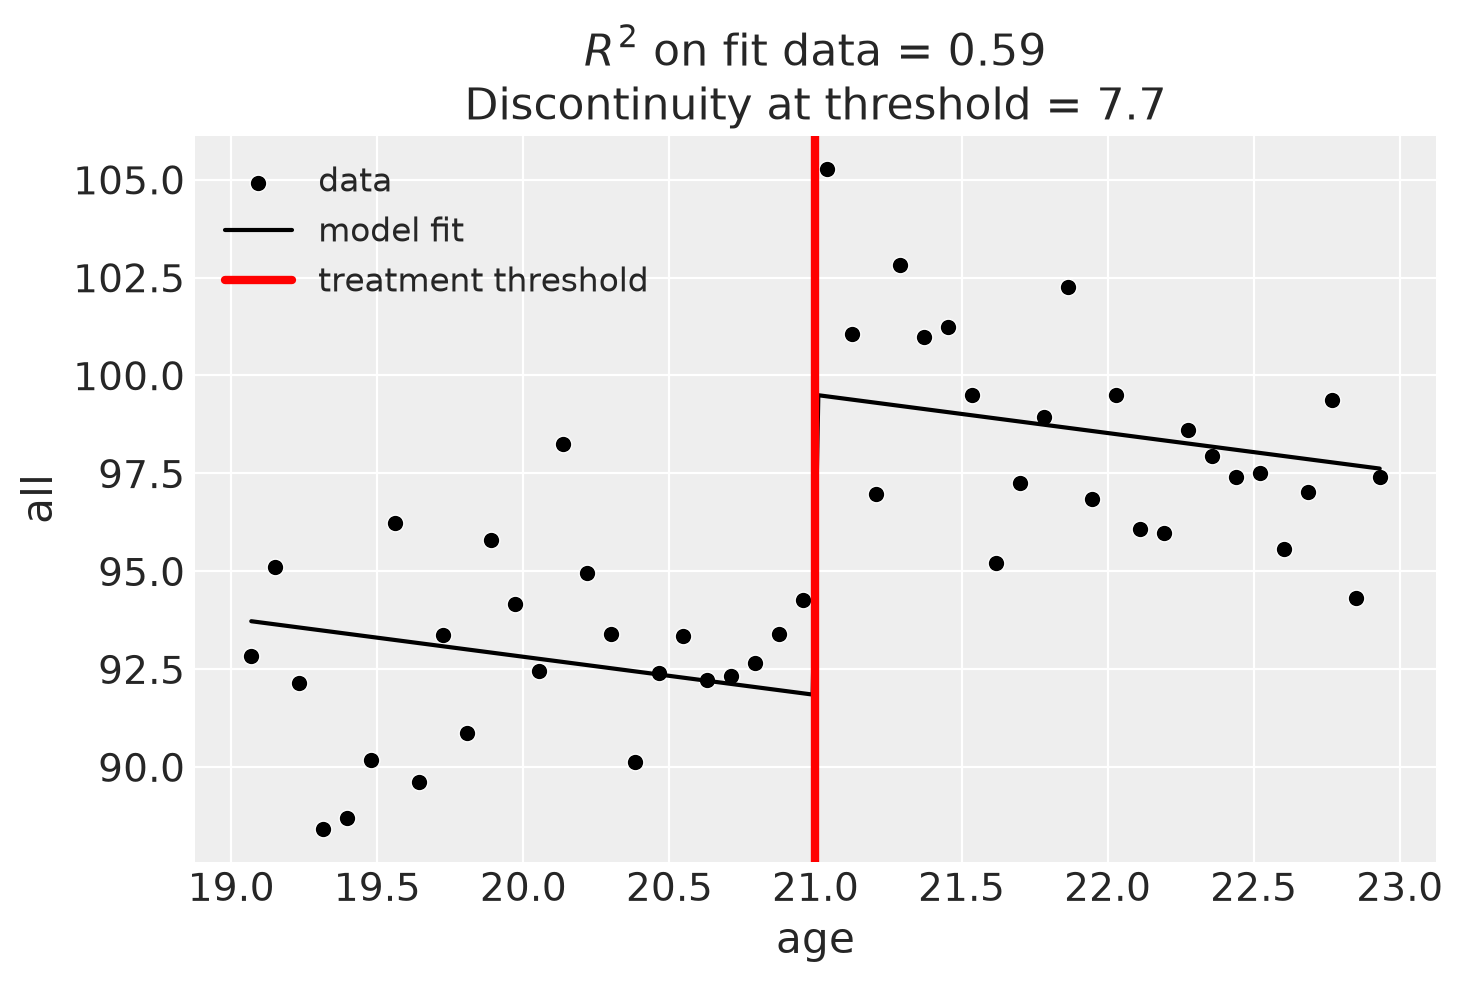

In [5]:
result.plot();

In [6]:
result.summary()

Regression Discontinuity experiment
Formula: all ~ 1 + age + treated
Running variable: age
Threshold on running variable: 21
Bandwidth: inf
Donut hole: 0.0
Observations used for fit: 48

Results:
Discontinuity at threshold = 7.66


Model coefficients:
  Intercept      	       112
  treated[T.True]	       7.7
  age            	     -0.97


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [7]:
from maketables import ETable

ETable(result, coef_fmt="b:.3f")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x17fc2cc20>